In [3]:

%matplotlib inline
import jax.numpy as jnp
from jax import value_and_grad
from jax import grad
from jax import random
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as snb
import numpy as np


###Bayesian ML functions###

from bayesian_ml import *
from packages.BayesianLinearRegression import BayesianLinearRegression
from packages.LogisticRegression import LogisticRegression
from packages.Grid2D import Grid2D
from packages.LaplaceApproximation import LaplaceApproximation
from packages.PosteriorPredictiveDistribution import PosteriorPredictiveDistribution
from packages.Hyperparameters import Hyperparameters
from packages.StationaryIsotropicKernel import StationaryIsotropicKernel
from packages.GaussianProcessRegression import GaussianProcessRegression
from packages.BayesianLinearSoftmax import BayesianLinearSoftmax
from packages.metropolis import metropolis



###Distributions###
from scipy.stats import multivariate_normal as mvn
from scipy.stats import poisson



snb.set_theme(font_scale=1.25)

In [2]:
def generate_samples(key, m, K, num_samples, jitter=0):
    """ returns M samples from an Gaussian process with mean m and kernel matrix K. The function generates num_samples of z ~ N(0, I) and transforms them into f  ~ N(m, K) via the Cholesky factorization.

    
    arguments:
        key              -- jax random key for controlling the random number generator
        m                -- mean vector (shape (N,))
        K                -- kernel matrix (shape NxN)
        num_samples      -- number of samples to generate (positive integer)
        jitter           -- amount of jitter (non-negative scalar)
    
    returns 
        f_samples        -- a numpy matrix containing the samples of f (shape N x num_samples)
    """

    # generate samples from N(0, 1) of shape (N, num_samples)
    zs = random.normal(key, shape=(len(K), num_samples))

    ##############################################
    # Your solution goes here
    ##############################################
    
    N = len(K)
    L = jnp.linalg.cholesky(K + jitter*jnp.identity(N))
    f_samples = m[:, None] + jnp.dot(L, zs)
    
    ##############################################
    # End of solution
    ##############################################

    # sanity check of dimensions
    assert f_samples.shape == (len(K), num_samples), f"The shape of f_samples appears wrong. Expected shape ({len(K)}, {num_samples}), but the actual shape was {f_samples.shape}. Please check your code. "
    return f_samples


@dataclass
class Hyperparameters(object):
    kappa:          float = 1.0 # magnitude, positive scalar (default=1.0)
    lengthscale:    float = 1.0 # characteristic lengthscale, positive scalar (default=1.0)
    sigma:          float = 1.0 # noise std. dev., positive scalar (default=1.0)

    def to_array(self):
        """ return hyperparameters as flat JaX-array (to be used later) """
        return jnp.array([self.kappa, self.lengthscale, self.sigma])
        
    @staticmethod
    def from_array(hyper_array):
        """ instantiates Hyperparameter object from flat JaX-array (or list) of hyperparameters (to be used later) """
        kappa, lengthscale, sigma = hyper_array
        return Hyperparameters(kappa, lengthscale, sigma)
    
    def __repr__(self):
        """ for reporting hyperparameter values """
        return f'Hyperparameters(kappa={self.kappa:3.2f}, lengthscale={self.lengthscale:3.2f}, sigma={self.sigma:3.2f})'

hyperparameters = Hyperparameters(kappa=2.0, lengthscale=0.5)
hyperparameters
def squared_exponential(tau, hyperparameters):
    return hyperparameters.kappa**2*jnp.exp(-0.5*tau**2/hyperparameters.lengthscale**2)

class StationaryIsotropicKernel(object):

    def __init__(self, kernel_fun):
        """
            the argument kernel_fun must be a function of two arguments kernel_fun(||tau||, hyperparameters), e.g. 
            squared_exponential = lambda tau, hyper: hyper.kappa**2*np.exp(-0.5*tau**2/hyper.lengthscale**2).
        """
        self.kernel_fun = kernel_fun

    def construct_kernel(self, X1, X2, hyperparameters, jitter=1e-8):
        """ compute and returns the NxM kernel matrix between the two sets of input X1 (shape NxD) and X2 (MxD) using the stationary and isotropic covariance function specified by self.kernel_fun
    
        arguments:
            X1              -- NxD matrix
            X2              -- MxD matrix or None
            hyperparameters -- Hyperparameter object compatible with self.kernel_fun function
            jitter          -- non-negative scalar
        
        returns
            K               -- NxM matrix    
        """

        # extract dimensions 
        N, M = X1.shape[0], X2.shape[0]

        ##############################################
        # Your solution goes here
        ##############################################
        
        # compute all the pairwise distances efficiently (can also be done using nested for loops)
        dists = jnp.sqrt(jnp.sum((jnp.expand_dims(X1, 1) - jnp.expand_dims(X2, 0))**2, axis=-1))
        
        # squared exponential covariance function
        K = self.kernel_fun(dists, hyperparameters)
        
        # add jitter to diagonal for numerical stability
        if len(X1) == len(X2) and jnp.allclose(X1, X2):
            K = K + jitter*jnp.identity(len(X1))
        
        ##############################################
        # End of solution
        ##############################################
        
        assert K.shape == (N, M), f"The shape of K appears wrong. Expected shape ({N}, {M}), but the actual shape was {K.shape}. Please check your code. "
        return K
    
def plot_with_uncertainty(ax, Xp, gp, color='r', color_samples='b', title="", num_samples=0, seed=0):
    
    mu, Sigma = gp.predict_y(Xp)
    mean, std = mu.ravel(), jnp.sqrt(jnp.diag(Sigma))

    # random seed
    key = random.PRNGKey(seed)

    # plot distribution
    ax.plot(Xp, mean, color=color, label='Mean')
    ax.plot(Xp, mean + 2*std, color=color, linestyle='--')
    ax.plot(Xp, mean - 2*std, color=color, linestyle='--')
    ax.fill_between(Xp.ravel(), mean - 2*std, mean + 2*std, color=color, alpha=0.25, label='95% interval')
    
    # generate samples
    if num_samples > 0:
        fs = gp.posterior_samples(key, Xstar, num_samples)
        ax.plot(Xp, fs[:,0], color=color_samples, alpha=.25, label="$f(x)$ samples")
        ax.plot(Xp, fs[:, 1:], color=color_samples, alpha=.25)
    ax.set_title(title)
    

class GaussianProcessRegression(object):

    def __init__(self, X, y, kernel, hyperparameters, jitter=1e-8):
        """  
        Arguments:
            X                -- NxD input points
            y                -- Nx1 observed values 
            kernel           -- must be instance of the StationaryIsotropicKernel class
            jitter           -- non-negative scaler
            hyperparameters  -- Hyperparameter object containing kernel hyperparameters and noise std. dev. 
        """
        self.X = X
        self.y = y
        self.N = len(X)
        self.kernel = kernel
        self.jitter = jitter
        self.set_hyperparameters(hyperparameters)
        self.check_dimensions()

    def check_dimensions(self):
        N, D = self.X.shape
        assert self.X.ndim == 2, f"The variable X must be of shape (N, D), however, the current shape is: {self.X.shape}"
        assert self.y.ndim == 2, f"The varabiel y must be of shape (N, 1), however. the current shape is: {self.y.shape}"
        assert self.y.shape == (N, 1), f"The varabiel y must be of shape (N, 1), however. the current shape is: {self.y.shape}"

    def set_hyperparameters(self, hyper):
        self.hyperparameters = hyper
        
    def posterior_samples(self, key, Xstar, num_samples):
        """
            generate samples from the posterior p(f^*|y, x^*) for each of the inputs in Xstar

            Arguments:
                key              -- jax random key for controlling the random number generator
                Xstar            -- PxD prediction points
        
            returns:
                f_samples        -- numpy array of (P, num_samples) containing num_samples for each of the P inputs in Xstar
        """
        ##############################################
        # Your solution goes here
        ##############################################
        
        mu, Sigma = self.predict_f(Xstar)
        f_samples = generate_samples(key, mu.ravel(), Sigma, num_samples)
        
        ##############################################
        # End of solution
        ##############################################

        assert (f_samples.shape == (len(Xstar), num_samples)), f"The shape of the posterior mu seems wrong. Expected ({len(Xstar)}, {num_samples}), but actual shape was {f_samples.shape}. Please check implementation"
        return f_samples
        
    def predict_y(self, Xstar):
        """ returns the posterior distribution of y^* evaluated at each of the points in x^* conditioned on (X, y)
        
        Arguments:
        Xstar            -- PxD prediction points
        
        returns:
        mu               -- Px1 mean vector
        Sigma            -- PxP covariance matrix
        """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare relevant matrices
        mu, Sigma = self.predict_f(Xstar)
        Sigma = Sigma + self.hyperparameters.sigma**2 * jnp.identity(len(mu))
        
        ##############################################
        # End of solution
        ##############################################

        return mu, Sigma

    def predict_f(self, Xstar):
        """ returns the posterior distribution of f^* evaluated at each of the points in x^* conditioned on (X, y)
        
        Arguments:
        Xstar            -- PxD prediction points
        
        returns:
        mu               -- Px1 mean vector
        Sigma            -- PxP covariance matrix
        """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare relevant matrices
        k = self.kernel.construct_kernel(Xstar, self.X, self.hyperparameters, jitter=self.jitter)
        K = self.kernel.construct_kernel(self.X, self.X, self.hyperparameters, jitter=self.jitter)
        Kstar = self.kernel.construct_kernel(Xstar, Xstar, self.hyperparameters, jitter=self.jitter)
        
        # Compute C matrix
        C = K + self.hyperparameters.sigma**2*jnp.identity(len(self.X)) 

        # computer mean and Sigma
        mu = jnp.dot(k, jnp.linalg.solve(C, self.y))
        Sigma = Kstar - jnp.dot(k, jnp.linalg.solve(C, k.T))
        
        ##############################################
        # End of solution
        ##############################################

        # sanity check for dimensions
        assert (mu.shape == (len(Xstar), 1)), f"The shape of the posterior mu seems wrong. Expected ({len(Xstar)}, 1), but actual shape was {mu.shape}. Please check implementation"
        assert (Sigma.shape == (len(Xstar), len(Xstar))), f"The shape of the posterior Sigma seems wrong. Expected ({len(Xstar)}, {len(Xstar)}), but actual shape was {Sigma.shape}. Please check implementation"

        return mu, Sigma
    
    def log_marginal_likelihood(self, hyperparameters):
        """ 
            evaluate the log marginal likelihood p(y) given the hyperparaemters 

            Arguments:
                hyperparameters  -- Hyperparameter object containing kernel hyperparameters and noise std. dev. 
            """

        ##############################################
        # Your solution goes here
        ##############################################
        
        # prepare kernels
        K = self.kernel.construct_kernel(self.X, self.X, hyperparameters)
        C = K + hyperparameters.sigma**2*jnp.identity(self.N)

        # compute Cholesky decomposition
        L = jnp.linalg.cholesky(C)
        v = jnp.linalg.solve(L, self.y)

        # compute log marginal likelihood
        logdet_term = jnp.sum(jnp.log(jnp.diag(L)))
        quad_term =  0.5*jnp.sum(v**2)
        const_term = -0.5*self.N*jnp.log(2*jnp.pi)

        return const_term - logdet_term - quad_term
        
        ##############################################
        # End of solution
        ##############################################
        

    
def softmax(a_, axis=1):
    max_val = jnp.max(a_, axis=axis)                # get maximum value along axis
    a = a_ - jnp.expand_dims(max_val, axis=axis)    # subtract max value for numerical stability
    exp_a = jnp.exp(a)                                
    return exp_a/jnp.sum(exp_a, axis=axis)[:, None]

def compute_entropy(pi):
    """ assumes pi is [N, K] where N is the number of prediction points and K is the number of classes """ 
    log_pi = jnp.where(pi > 0, jnp.log(pi), 0)  # equal to log(p) when p > 0 else 0
    H = -jnp.sum(pi*log_pi, 1)
    return H

def compute_confidence(pi):
    """ assumes pi is [N, K] where N is the number of prediction points and K is the number of classes """
    return jnp.max(pi, 1)

NameError: name 'dataclass' is not defined

<h1>Part 1<h1>

<h2>Question 1.2<h2>

We define $\hat{W}_{\text{MAP}}$

In [ ]:
W_map = jnp.array([[-0.5, -2.0],[3, 0],[1,1]])
W_map

Array([[-0.5, -2. ],
       [ 3. ,  0. ],
       [ 1. ,  1. ]], dtype=float64)

Then we compute $\text{Categorical}[\text{softmax}(\bold{f}_{n})]$

In [ ]:
xtest = jnp.array([-1])[:, None]

def design_matrix(x):
    return jnp.column_stack((jnp.ones(len(x)), x))

phi = design_matrix(xtest)

In [ ]:
softmax(phi @ W_map.T)

Array([[0.17529039, 0.78559703, 0.03911257]], dtype=float64)

<h2>Question 1.3<h2>

In [ ]:
W1 = jnp.array([[-0.15, -1.92],[3.2,0.45],[1.37, 0.8]])
W2 = jnp.array([[-0.31, -2.03],[2.98,0.08],[1.03, 1.29]])
W3 = jnp.array([[-0.35, -1.98],[3.09,0.07],[1.3, 0.96]])

W = [W1,W2,W3]

np.mean([softmax(phi @ w.T) for w in W], axis = 0)


array([[0.22295359, 0.72390675, 0.05313967]])

<h2>Question 1.4<h2>

In [ ]:
pi = jnp.array([0,0.27,0.73])[None, :]
entropy = compute_entropy(pi)
confidence = compute_confidence(pi)

print(entropy, confidence)

[0.58325884] [0.73]


<h1> Part 2<h2>

<h2>Question 2.1<h2>

Since the Squared exponential kernel has the following form:
\begin{align*}
    k_{\text{SE}}(\mathbf{x}_n, \mathbf{x}_m) = \kappa^2 \exp\left(-\frac{\|\mathbf{x}_n - \mathbf{x}_m\|^2_ 2}{2\ell^2}\right) = \kappa^2 \exp\left(-\frac{\|\tau\|^2_ 2}{2\ell^2}\right) = k(\tau).
\end{align*}

$2\ell^{2} = 8 \Rightarrow \ell = 2$
and
$\kappa^{2} = 2 \Rightarrow \kappa = \sqrt{2}$

<h2> Question 2.2 <h2>

In [ ]:
Xtrain = jnp.array([-2,0,2])[:,None]
ytrain = jnp.array([-2.01, 1.41, 0.23])[:, None]

hyperparameters = Hyperparameters(kappa=jnp.sqrt(2), lengthscale=2, sigma = 1/2)

kernel = StationaryIsotropicKernel(kernel_fun= squared_exponential)
S = kernel.construct_kernel(X1 = Xtrain, X2 = Xtrain, hyperparameters=hyperparameters)
m = jnp.array([0,0,0])

print(m,S)

[0 0 0] [[2.00000001 1.21306132 0.27067057]
 [1.21306132 2.00000001 1.21306132]
 [0.27067057 1.21306132 2.00000001]]


<h2>Question 2.3<h2>

In [ ]:
model = GaussianProcessRegression(X = Xtrain, y = ytrain, kernel = kernel, hyperparameters=hyperparameters)
model.predict_f(Xstar=Xtrain)

(Array([[-1.52833703],
        [ 0.8865026 ],
        [ 0.42873887]], dtype=float64),
 Array([[ 0.20844192,  0.02778709, -0.00998173],
        [ 0.02778709,  0.19226005,  0.02778709],
        [-0.00998173,  0.02778709,  0.20844192]], dtype=float64))

<h2> Question 2.4 <h2>

# Part 3

## Question 3.1

In [6]:
Phi_train = jnp.array([[1,0.5],[-1,1]])
ytrain = jnp.array([1,0])[:, None]

model = BayesianLinearRegression(Phi = Phi_train, y = ytrain, alpha = 1, beta = 1)

model.w_MLE()


Array([0.66666667, 0.66666667], dtype=float64)

## Question 3.2

In [13]:
from scipy.stats import multivariate_normal as mvn

m = jnp.array([1,1])
tau = 1

theta0 = jnp.array([0,0])
result = (1/2) * mvn.pdf(theta0, m, jnp.eye(2) * tau) + (1/2) * mvn.pdf(theta0, -m, jnp.eye(2) * tau)
result

np.float64(0.05854983152431917)

## Question 3.4

In [25]:
y = jnp.array([1,0])
sigma = 1
prior = lambda theta: (1/2) * mvn.pdf(theta, m, jnp.eye(2) * tau) + (1/2) * mvn.pdf(theta, -m, jnp.eye(2) * tau)
likelihood = lambda theta: mvn.pdf(y, Phi_train @ theta, jnp.eye(2))
evidence = 1/2 * (mvn.pdf(y, Phi_train @ -m, jnp.eye(2) + Phi_train @ Phi_train.T))  + (1/2) * mvn.pdf(y, Phi_train @ m, jnp.eye(2) + Phi_train @ Phi_train.T) 

likelihood(theta0) * prior(theta0) / evidence

np.float64(0.15341385696171722)

# Part 4

In [6]:
X = jnp.array([1, 2, 3])[:, None]
y = jnp.array([10, 4, 1])[:, None]
alpha = 8

log_target = lambda w: jnp.sum(poisson.logpmf(y, jnp.exp(3 + w[0]*X + w[1]*X**2))) + mvn.logpdf(w, jnp.zeros(len(w)), alpha**-1 * jnp.identity(len(w)))

w_init = jnp.array([0,0])
MCMC = metropolis(log_target=log_target, num_params=2, tau=1, num_iter=10**4, theta_init=w_init, dis_prop=0.5)

Acceptance ratio: 0.04


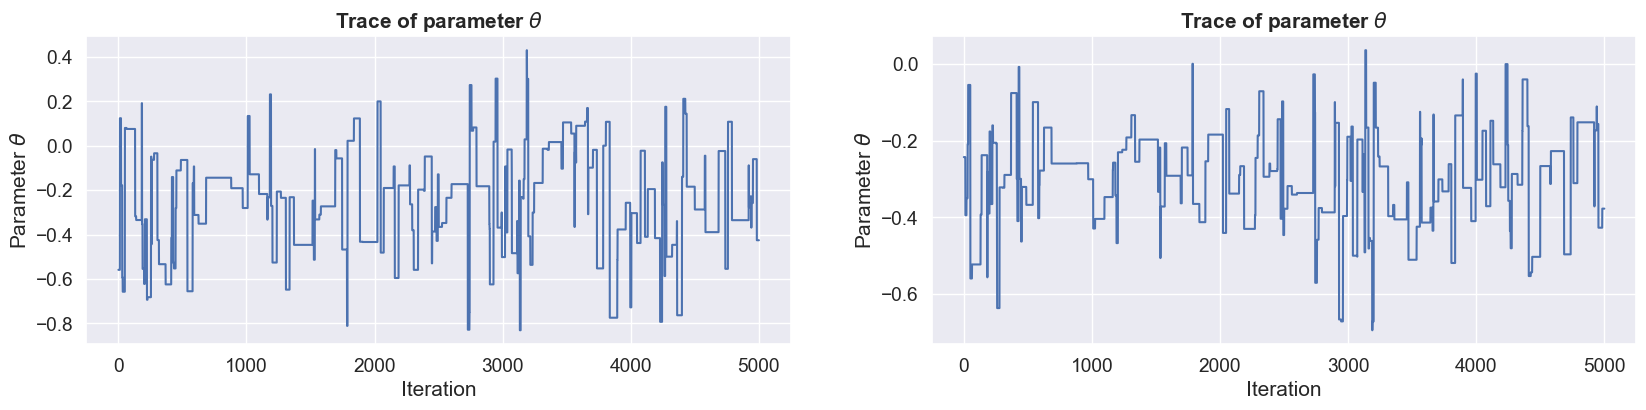

In [8]:
MCMC.plot_trace()

In [9]:
jnp.mean(MCMC.post_warmup_thetas[:,0] > 0)

Array(0.14957008, dtype=float32)

In [18]:
xn = 1.5
mu = jnp.exp(3 + MCMC.post_warmup_thetas @ jnp.array([xn, xn**2]))
jnp.mean(mu > 7)

Array(0.49830034, dtype=float32)

In [24]:
random.key(seed=0)

Array((), dtype=key<fry>) overlaying:
[0 0]

In [29]:
jnp.mean(jnp.exp(3 + MCMC.post_warmup_thetas[:, 0]*xn + MCMC.post_warmup_thetas[:,1]*xn**2) > 7)

Array(0.49830034, dtype=float32)

In [ ]:
random.poisson()

In [30]:
yi = random.poisson(key=random.key(seed=0), lam=mu)
jnp.percentile(yi, jnp.array([5, 95]))

Array([ 3., 13.], dtype=float64)

# Part 5

## Question 5.1

In [3]:
S = 1000

key = random.key(seed = 1000)
w_key, y_key = random.split(key,2)

w = random.normal(key = w_key,shape = (S,))
y = jnp.exp(w) + random.normal(key = y_key, shape=(S,))

jnp.mean(y)

Array(1.66442714, dtype=float64)

## Question 5.2

In [22]:
y = 5
w_map = 1.293404

mvn.logpdf(w_map,0,1) + mvn.logpdf(y, jnp.exp(w_map),1)

np.float64(-3.5921012636887815)

## Question 5.3

In [38]:
log_npdf = lambda x, m, v: -0.5*jnp.log(2*jnp.pi*v) -0.5*(x-m)**2/v 

cost_func = lambda w: -(log_npdf(w, 0,1) + log_npdf(y, jnp.exp(w), 1))


A = hessian(cost_func, argnums=0)(w_map)
A**(-1)

Array(0.10696659, dtype=float64, weak_type=True)

In [ ]:
mvn.cdf()